In [1]:
  import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
  from sklearn.cluster import KMeans
  print("all good")

all good


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/fem_cleaned.csv")
INPUTS  = ["ecc","N","gammaG","Esoil","Econc","Dbot","H1","H2","H3"]
OUTPUTS = ["Mr_t","Mt_t","Mr_c","Mt_c"]
print(df.shape)
df.head()

(5184, 13)


,ecc,N,gammaG,Esoil,Econc,Dbot,H1,H2,H3,Mr_t,Mt_t,Mr_c,Mt_c
0,0,2000,0.9,25,30000,17,0.8,1.0,0.8,0.082100,0.055648,0.082100,0.055648
1,10,2000,0.9,25,30000,17,0.8,1.0,0.8,-0.597084,-0.233470,1.160648,0.605016
2,18,2000,0.9,25,30000,17,0.8,1.0,0.8,-1.094196,-0.566130,1.908188,0.947770
3,26,2000,0.9,25,30000,17,0.8,1.0,0.8,-1.416485,-0.865039,2.844706,1.310545
4,0,2000,0.9,25,37000,17,0.8,1.0,0.8,0.079570,0.054213,0.079570,0.054213


In [3]:
#Missing data, duplicates, structure-
print("Missing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate input combinations:", df.duplicated(INPUTS).sum())
for c in INPUTS:
    print(c, sorted(df[c].unique()))
expected = int(np.prod([df[c].nunique() for c in INPUTS]))
print("Complete grid?", expected == len(df), expected, len(df))
df.describe().T

Missing values:
 ecc       0
N         0
gammaG    0
Esoil     0
Econc     0
Dbot      0
H1        0
H2        0
H3        0
Mr_t      0
Mt_t      0
Mr_c      0
Mt_c      0
dtype: int64
Duplicate rows: 0
Duplicate input combinations: 0
ecc [0, 10, 18, 26]
N [2000, 5000]
gammaG [0.9, 1.1]
Esoil [25, 75]
Econc [30000, 37000]
Dbot [17, 20, 23]
H1 [0.8, 1.2, 1.6]
H2 [1.0, 1.5, 2.0]
H3 [0.8, 1.2, 1.6]
Complete grid? True 5184 5184


,count,mean,std,min,25%,50%,75%,max
ecc,5184.0,13.500000,9.631609,0.000000,7.500000,14.000000,20.000000,26.000000
N,5184.0,3500.000000,1500.144697,2000.000000,2000.000000,3500.000000,5000.000000,5000.000000
gammaG,5184.0,1.000000,0.100010,0.900000,0.900000,1.000000,1.100000,1.100000
Esoil,5184.0,50.000000,25.002412,25.000000,25.000000,50.000000,75.000000,75.000000
Econc,5184.0,33500.000000,3500.337626,30000.000000,30000.000000,33500.000000,37000.000000,37000.000000
Dbot,5184.0,20.000000,2.449726,17.000000,17.000000,20.000000,23.000000,23.000000
H1,5184.0,1.200000,0.326630,0.800000,0.800000,1.200000,1.600000,1.600000
H2,5184.0,1.500000,0.408288,1.000000,1.000000,1.500000,2.000000,2.000000
H3,5184.0,1.200000,0.326630,0.800000,0.800000,1.200000,1.600000,1.600000
Mr_t,5184.0,-1.629734,1.426607,-6.027412,-2.402849,-1.554450,-0.176328,0.251917


In [4]:
#Physics checks
z = df[df.ecc == 0]
print("max diff Mr:", (z.Mr_t - z.Mr_c).abs().max())
print("max diff Mt:", (z.Mt_t - z.Mt_c).abs().max())

others = ["N","gammaG","Esoil","Econc","Dbot","H1","H2","H3"]
for o in OUTPUTS:
    bad = 0
    for _, g in df.sort_values("ecc").groupby(others):
        d = np.diff(g[o].values)
        bad += (d < 0).any() if o.endswith("_c") else (d > 0).any()
    print(o, "groups that break the trend:", bad)

max diff Mr: 9.999999994736442e-10
max diff Mt: 7.000000024071085e-10
Mr_t groups that break the trend: 0
Mt_t groups that break the trend: 0
Mr_c groups that break the trend: 1
Mt_c groups that break the trend: 0


In [5]:
#Outlier detection
def iqr_flag(s, k=1.5):
    q1, q3 = s.quantile([.25, .75]); i = q3 - q1
    return (s < q1 - k*i) | (s > q3 + k*i)

def mad_flag(s, thr=3.5):
    m = s.median(); mad = (s - m).abs().median()
    return (0.6745 * (s - m) / mad).abs() > thr

glob = pd.DataFrame({c: iqr_flag(df[c]) for c in OUTPUTS})
grp  = pd.DataFrame({c: df.groupby("ecc")[c].transform(iqr_flag) for c in OUTPUTS})
mad  = pd.DataFrame({c: df.groupby("ecc")[c].transform(mad_flag) for c in OUTPUTS})

df["outlier_global"] = glob.any(axis=1)
df["outlier_group"]  = grp.any(axis=1)
df["outlier_mad"]    = mad.any(axis=1)

print("Global IQR:\n", glob.sum())
print("Per-ecc IQR:\n", grp.sum())
print("Per-ecc MAD:\n", mad.sum())
print(df[df.outlier_global].groupby(["ecc","N","Dbot"]).size())
print(df[df.outlier_group].groupby(["ecc","N","Dbot"]).size())

Global IQR:
 Mr_t     6
Mt_t     0
Mr_c    33
Mt_c     0
dtype: int64
Per-ecc IQR:
 Mr_t    28
Mt_t    30
Mr_c    28
Mt_c    30
dtype: int64
Per-ecc MAD:
 Mr_t    0
Mt_t    4
Mr_c    0
Mt_c    4
dtype: int64
ecc  N     Dbot
26   5000  17      33
           23       6
dtype: int64
ecc  N     Dbot
0    2000  23      18
     5000  23      18
dtype: int64


In [6]:
#Suspicious rows
sus = df[(df.ecc == 10) & (df.N == 2000) & (df.Dbot == 23) &
         (df.H1 == 1.2) & (df.H2 == 1.5) & (df.H3 == 1.6)]
print(sus[["gammaG","Esoil","Econc","Mr_c","Mt_c","Mr_t"]])
df["suspect_row"] = df.index.isin([4377, 4381])

      gammaG  Esoil  Econc      Mr_c      Mt_c      Mr_t
4353     0.9     25  30000  1.393278  0.899316 -0.615574
4357     0.9     25  37000  1.344461  0.914277 -0.640047
4361     0.9     75  30000  1.160349  0.809472 -0.942103
4365     0.9     75  37000  1.181106  0.811223 -0.925193
4369     1.1     25  30000  1.030503  0.820117 -1.053884
4373     1.1     25  37000  1.029868  0.821832 -1.056992
4377     1.1     75  30000  0.105264  0.856012 -1.662350
4381     1.1     75  37000  0.079713  0.854243 -1.699495


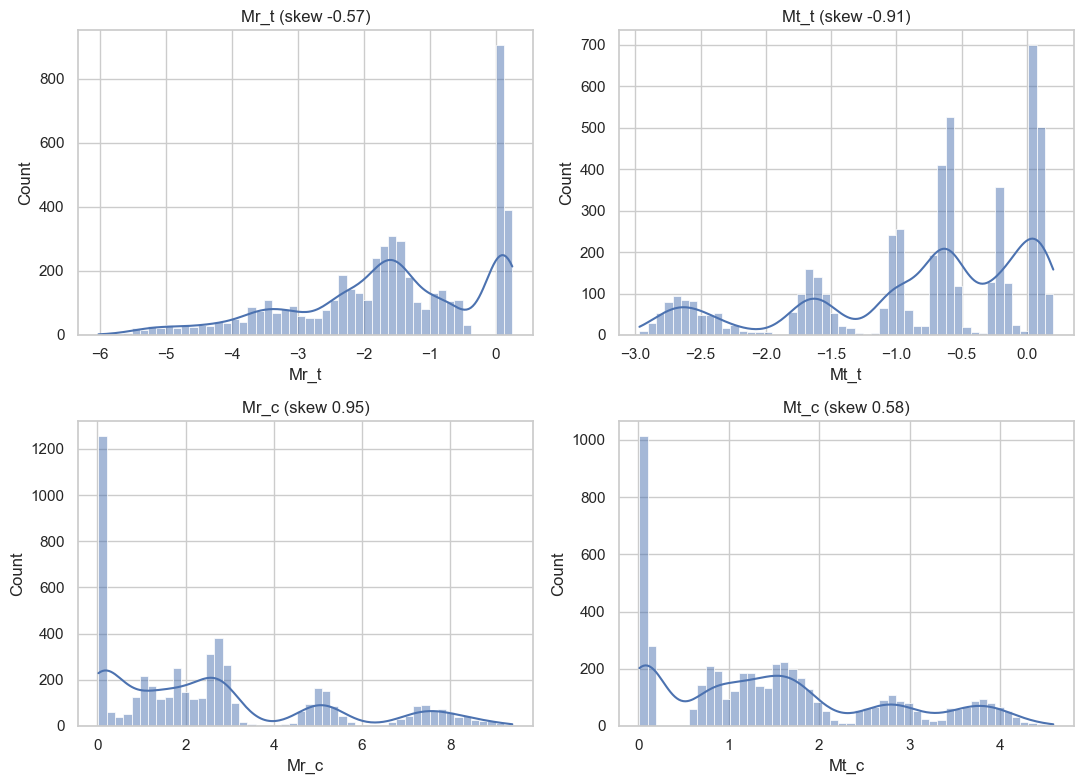

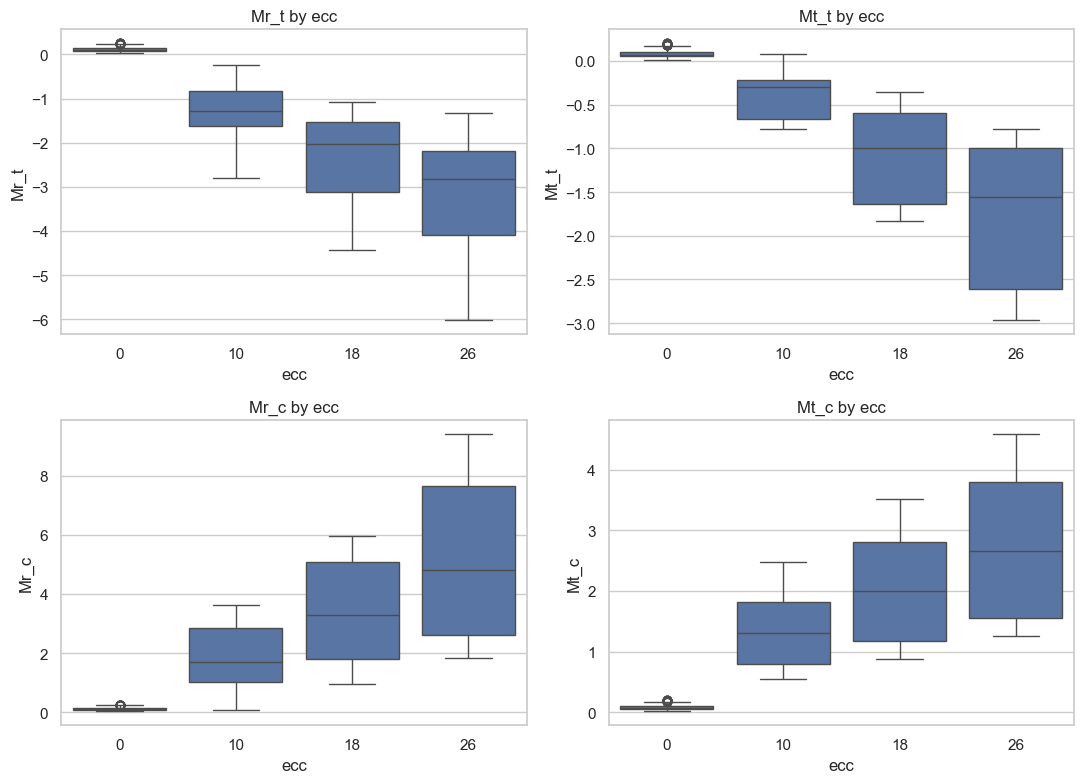

In [7]:
#Distributions
fig, ax = plt.subplots(2, 2, figsize=(11, 8))
for a, c in zip(ax.ravel(), OUTPUTS):
    sns.histplot(df[c], bins=50, kde=True, ax=a)
    a.set_title(f"{c} (skew {df[c].skew():.2f})")
plt.tight_layout(); plt.savefig("../figures/dist_outputs.png", dpi=200); plt.show()

fig, ax = plt.subplots(2, 2, figsize=(11, 8))
for a, c in zip(ax.ravel(), OUTPUTS):
    sns.boxplot(data=df, x="ecc", y=c, ax=a); a.set_title(f"{c} by ecc")
plt.tight_layout(); plt.savefig("../figures/box_by_ecc.png", dpi=200); plt.show()


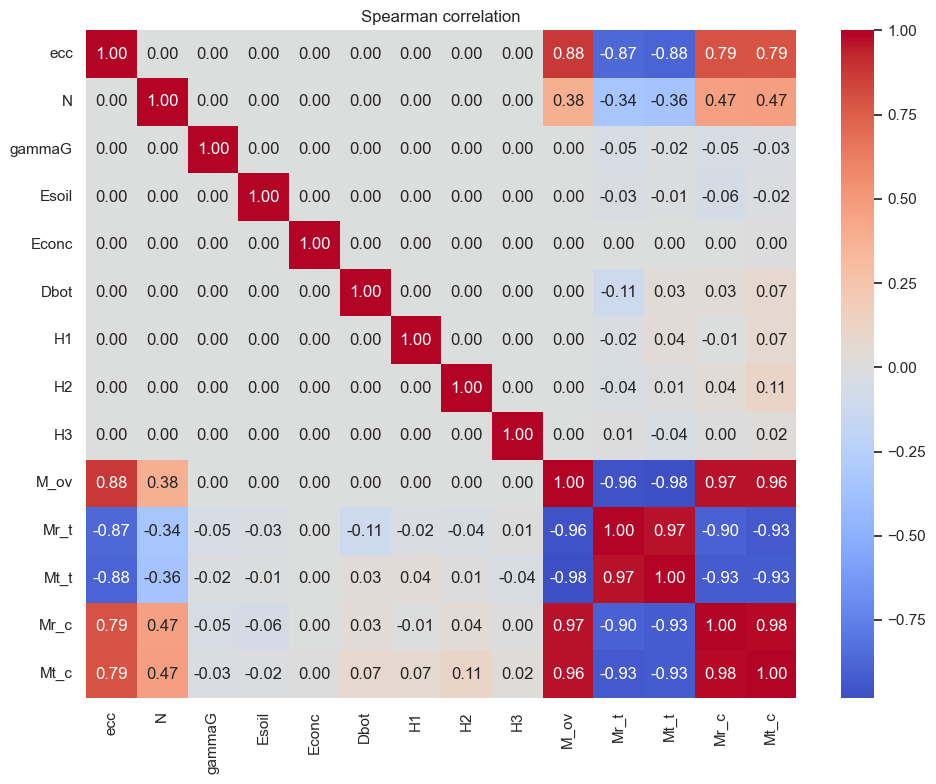

In [8]:
#Correlation
df["M_ov"] = df.N * df.ecc
corr = df[INPUTS + ["M_ov"] + OUTPUTS].corr(method="spearman")
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Spearman correlation"); plt.tight_layout()
plt.savefig("../figures/corr_heatmap.png", dpi=200); plt.show()

        Mr_t  Mt_t  Mr_c  Mt_c
ecc     2.26  2.17  2.04  2.13
N       0.75  0.89  1.04  1.00
gammaG  0.05  0.01  0.03  0.01
Esoil   0.03  0.01  0.05  0.02
Econc   0.00  0.00  0.00  0.00
Dbot    0.40  0.02  0.05  0.12
H1      0.11  0.01  0.04  0.10
H2      0.15  0.07  0.03  0.20
H3      0.02  0.05  0.03  0.03


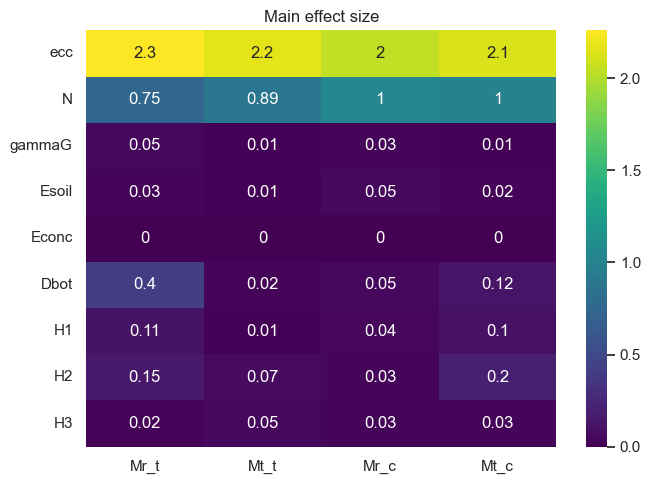

In [9]:
#Which inputs matter most
rows = []
for c in INPUTS:
    m = df.groupby(c)[OUTPUTS].mean()
    rows.append((m.max() - m.min()) / df[OUTPUTS].std())
effect = pd.DataFrame(rows, index=INPUTS).round(2)
print(effect)

plt.figure(figsize=(7, 5)); sns.heatmap(effect, annot=True, cmap="viridis")
plt.title("Main effect size"); plt.tight_layout()
plt.savefig("../figures/sensitivity_heatmap.png", dpi=200); plt.show()

In [10]:
#Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

d = df[df.ecc > 0].copy()
for o in OUTPUTS:
    d[o + "_n"] = d[o] / d.M_ov * 1000
NORM = [o + "_n" for o in OUTPUTS]
X = StandardScaler().fit_transform(d[NORM])

for k in range(2, 7):
    labels = KMeans(k, n_init=10, random_state=42).fit_predict(X)
    print(k, round(silhouette_score(X, labels), 3))


2 0.361
3 0.29
4 0.315
5 0.314
6 0.267


In [11]:
#Save for C
df.to_csv("../data/processed/data_with_flags.csv", index=False)


In [12]:
df.shape

(5184, 18)

In [13]:
df[df.outlier_mad].groupby(["ecc","N","Dbot"]).size()

ecc  N     Dbot
0    2000  23      2
     5000  23      2
dtype: int64

In [14]:
(df.outlier_mad & ~df.outlier_group).sum()


0

In [15]:
df[df.outlier_group].groupby(["H1","H2","H3"]).size()

H1   H2   H3 
1.2  1.5  1.6    4
     2.0  1.6    4
1.6  1.0  1.6    4
     1.5  1.6    4
     2.0  0.8    8
          1.2    4
          1.6    8
dtype: int64

In [16]:
for o in OUTPUTS:
    bad = 0
    for key, g in df.sort_values("ecc").groupby(others):
        d = np.diff(g[o].values)
        broke = (d < 0).any() if o.endswith("_c") else (d > 0).any()
        bad += broke
        if broke:
            print("\nBREAK in", o, "group (", ", ".join(f"{k}={v}" for k, v in zip(others, key)), ")")
            print(g[["ecc", o]].to_string(index=False))
    print(o, "groups that break the trend:", bad)

Mr_t groups that break the trend: 0
Mt_t groups that break the trend: 0

BREAK in Mr_c group ( N=2000, gammaG=1.1, Esoil=75, Econc=37000, Dbot=23, H1=1.2, H2=1.5, H3=1.6 )
 ecc     Mr_c
   0 0.097300
  10 0.079713
  18 0.960961
  26 1.832290
Mr_c groups that break the trend: 1
Mt_c groups that break the trend: 0
